In [1]:
import numpy as np
import pandas as pd

In [2]:
def gbm(num_years=10, mu=0.07, sigma=0.15, steps_per_year=12):
    dt = 1/steps_per_year
    num_steps = num_years*steps_per_year
    xi = np.random.normal(size=num_steps)
    r = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
    return pd.DataFrame(r)

<Axes: >

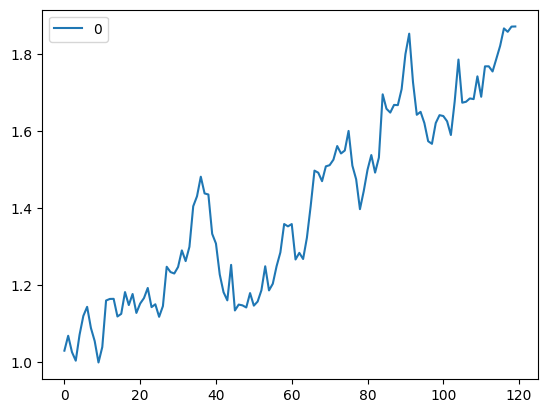

In [3]:
r = gbm()
wealth_index = (1+r).cumprod()
wealth_index.plot()

In [4]:
def gbm(num_years=10, num_scenarios=50, mu=0.07, sigma=0.15, steps_per_year=12):
    dt = 1/steps_per_year
    num_steps = num_years*steps_per_year
    xi = np.random.normal(size=(num_steps, num_scenarios))
    r = ((1+mu)**dt)-1 + sigma*np.sqrt(dt)*xi
    return pd.DataFrame(r)

<Axes: >

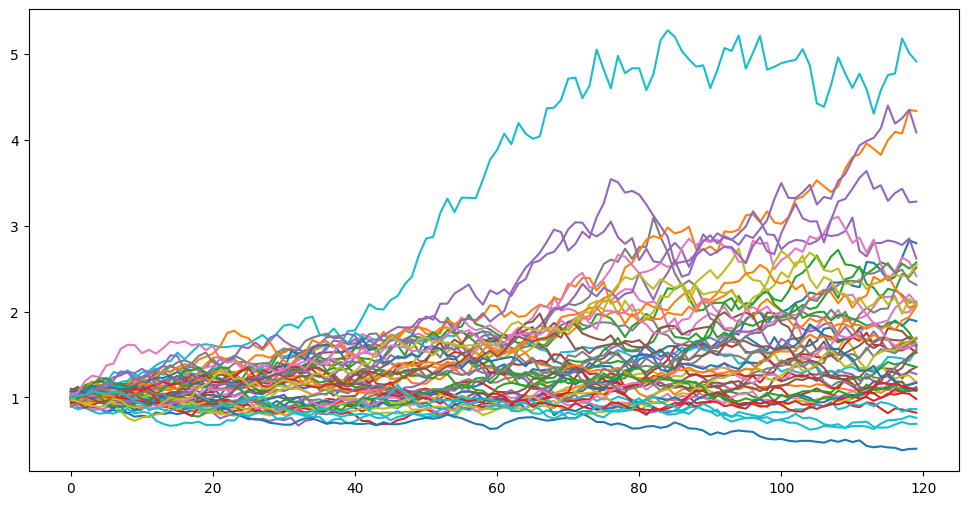

In [5]:
r = gbm()
wealth_index = (1+r).cumprod()
wealth_index.plot(legend=False, figsize=(12, 6))

In [6]:
def gbm(num_years=10, num_scenarios=50, mu=0.07, sigma=0.15, steps_per_year=12, s_0=100):
    dt = 1/steps_per_year
    num_steps = num_years*steps_per_year
    r_p = np.random.normal(loc=((1+mu)**dt), scale=sigma*np.sqrt(dt), size=(num_steps, num_scenarios))
    r_p = pd.concat([pd.DataFrame(np.ones((1, num_scenarios))), pd.DataFrame(r_p)], ignore_index=True)
    return s_0*pd.DataFrame(r_p).cumprod(0)

<Axes: >

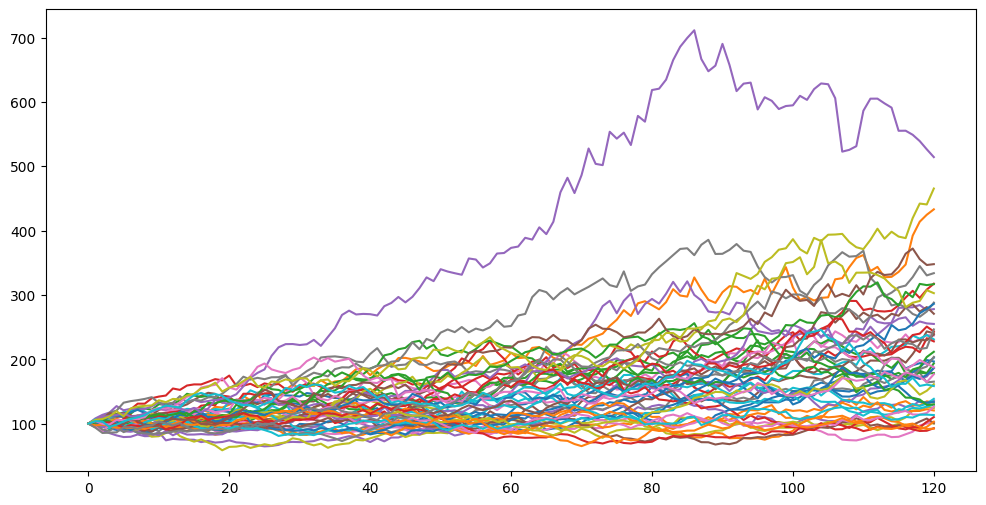

In [7]:
gbm().plot(legend=False, figsize=(12, 6))